# 1. Neural Networks as Supervised Learning Models

In the previous notebooks, we used several supervised machine learning models to classify molecules as active or inactive in a PubChem bioassay dataset. These models included Naive Bayes, Decision Trees, Random Forests, Logistic Regression, and Support Vector Machines. Each model used the same general supervised learning framework:

1. represent each molecule with numerical features,
2. train a model using molecules with known activity labels,
3. use the trained model to predict the activity class of new molecules,
4. evaluate the predictions with metrics such as accuracy, precision, recall, F1 score, balanced accuracy, ROC curves, and AUC.

In this notebook, we introduce another important family of supervised learning models: **neural networks**. A neural network is a model that learns relationships between input features and output labels by passing information through layers of connected mathematical units. In our case, the input features are molecular fingerprints, such as MACCS keys, and the output label is the predicted activity class.

For this dataset, the basic idea is:

```text
MACCS fingerprint bits → neural network → predicted activity class
```
Each molecule is represented by a binary fingerprint of 0s and 1s (the MACCS fingerprints). The neural network learns numerical weights that connect these input features to one or more intermediate layers and then to an output prediction. During training, the model adjusts these weights so that its predictions better match the known activity labels in the training data. 

The specific neural network model we will use is called a multilayer perceptron, or **MLP**. The word perceptron refers to an early artificial neuron model used for classification. A perceptron takes input features, multiplies them by learned weights, adds them together, and applies a decision rule to produce a class prediction. An MLP extends this idea by arranging many perceptron-like units into layers, allowing the model to learn more complex relationships between input features and output labels. 

An MLP is a feed-forward neural network, meaning information moves in one direction:

`input layer → hidden layer(s) → output layer`

The input layer receives the molecular fingerprint features. The hidden layer or layers learn combinations of those features. The output layer produces the final prediction, such as inactive or active. 

In this notebook, we will use scikit-learn’s `MLPClassifier`. This is useful because it allows us to introduce neural networks without changing the overall workflow used in the earlier supervised learning notebooks. We can still use familiar scikit-learn tools such as:
```python
Pipeline()
fit()
predict()
predict_proba()
confusion_matrix()
roc_auc_score()
```

This means that MLPClassifier can be compared directly with the other classifiers we have already studied.

## 1.1 Neural Networks and Deep Learning
Neural networks are closely associated with deep learning, but the terms are not exactly identical. A neural network is a model made from connected layers of mathematical units. A deep learning model is usually a neural network with multiple learned layers, especially when the model is large enough or flexible enough to learn increasingly abstract internal representations from data. The word deep refers mainly to the number of sequential learned layers between the input and the output. A very simple neural network with only one hidden layer is usually described as a neural network rather than a deep learning model.

An MLP can therefore be either a relatively small neural network or, if it has many hidden layers, a type of deep neural network. The difference is not a sharp boundary. In practice, the phrase deep learning is often used for larger neural-network models trained with specialized frameworks such as TensorFlow or PyTorch, often using GPUs, large datasets, custom architectures, and more complex data types. TensorFlow and PyTorch are not themselves MLPs; rather, they are software frameworks that can be used to build many kinds of neural networks, including MLPs, convolutional neural networks, recurrent neural networks, graph neural networks, and transformer-based models.

We will not use TensorFlow or PyTorch in this notebook because our goal is not to teach deep learning as a separate topic. Instead, our goal is to understand how a neural network can function as another supervised classifier within the same scikit-learn model-evaluation framework we have used throughout this module.

## 1.2 From Logistic Regression to Neural Networks

One useful way to understand a neural network is to compare it with logistic regression. In an earlier notebook, we used logistic regression as a supervised classifier. Logistic regression takes the input features, learns a weight for each feature, combines those weighted features, and converts the result into a probability for the positive class.

For this dataset, the idea can be summarized as:

```text
MACCS fingerprint bits → weighted sum → probability of active`
```
The model then applies a decision threshold, often 0.5, to convert that probability into a predicted class:

```text
probability of active ≥ threshold → predict active
probability of active < threshold → predict inactive
```
A neural network extends this idea. Instead of sending the weighted combination of input features directly to the output prediction, a neural network passes information through one or more hidden layers. These hidden layers allow the model to learn intermediate combinations of the original features.

For an MLP classifier, the idea is:
```text
MACCS fingerprint bits → hidden layer(s) → probability of active
```

Each hidden layer contains units that learn weighted combinations of values from the previous layer. The output of one layer becomes the input to the next layer. This allows the model to learn relationships that may be more complex than a single direct weighted sum of the original features.

This is the major conceptual difference between logistic regression and an MLP:

| Model               | Simplified structure                                  | Type of relationship                     |
| ------------------- | ----------------------------------------------------- | ---------------------------------------- |
| Logistic Regression | input features → output probability                   | linear combination of input features     |
| MLP Classifier      | input features → hidden layer(s) → output probability | nonlinear combinations of input features |

The term nonlinear is important. Logistic regression can be very useful, but it is limited by the fact that it learns one weighted combination of the input features. An MLP can learn combinations of combinations. For molecular fingerprints, this means the model may learn patterns involving groups of fingerprint bits rather than treating each bit only through a single direct weight.

However, this added flexibility also comes with risks. A neural network can overfit the training data if the model is too complex, the dataset is too small, or the training process is not well controlled. Therefore, neural networks still need the same careful evaluation workflow we have used throughout this course: train/test splits, confusion matrices, precision, recall, F1 score, ROC curves, AUC, and comparison with simpler models.

## 1.3 Why Use scikit-learn’s `MLPClassifier`?

In this notebook, we will use scikit-learn’s `MLPClassifier` to build a neural-network classifier. This is a good starting point because `MLPClassifier` works like the other scikit-learn classifiers we have already used. It can be placed inside a `Pipeline`, trained with `.fit()`, used for class predictions with `.predict()`, and used for predicted probabilities with `.predict_proba()`.

This lets us introduce a neural network without changing the overall supervised machine learning workflow:

```text
prepare features → split data → build pipeline → train model → predict → evaluate
```
A basic `MLPClassifier pipeline might look like this:
```python
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    ("var_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(50,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=1000,
        random_state=3100,
        early_stopping=True
    ))
])
```
The `VarianceThreshold` step removes fingerprint bits that do not vary across the dataset, just as we did with earlier models. The `MLPClassifier` step then trains the neural-network classifier on the remaining fingerprint features.

The table below summarizes several important `MLPClassifier` parameters.

Then include this table:

| Parameter | Common argument(s) | What it controls | Teaching note |
|---|---:|---|---|
| `hidden_layer_sizes` | `(50,)`, `(100,)`, `(100, 50)` | The number of hidden layers and the number of units in each hidden layer | `(50,)` means one hidden layer with 50 units; `(100, 50)` means two hidden layers |
| `activation` | `"relu"`, `"logistic"`, `"tanh"` | The function used by hidden-layer units | `"relu"` is the default and is commonly used in neural networks |
| `solver` | `"adam"`, `"lbfgs"`, `"sgd"` | The optimization method used to adjust weights during training | `"adam"` is the default and is a good general-purpose starting point |
| `alpha` | `0.0001`, `0.001`, `0.01` | L2 regularization strength | Larger values penalize large weights more strongly and can reduce overfitting |
| `max_iter` | `500`, `1000`, `2000` | Maximum number of training iterations | If the model does not converge, increasing this may help |
| `random_state` | `3100` | Controls reproducibility | Important because neural networks involve random weight initialization |
| `early_stopping` | `True`, `False` | Whether training stops when validation performance stops improving | Useful for reducing overfitting |
| `validation_fraction` | `0.1`, `0.2` | Fraction of training data used as validation data when `early_stopping=True` | This validation set is taken from the training data, not from the test set |
| `learning_rate_init` | `0.001`, `0.0005`, `0.01` | Initial step size used by stochastic solvers | Too large can make training unstable; too small can make training slow |
| `tol` | `1e-4`, `1e-5` | Tolerance for deciding whether training is still improving | Smaller values require more improvement before stopping |
| `n_iter_no_change` | `10`, `20`, `50` | Number of iterations with no improvement before stopping | Relevant when using early stopping or convergence checks |

The most important parameters to understand at the start are:

  - hidden_layer_sizes, which controls the architecture of the neural network,
  - activation, which controls how hidden-layer units transform their inputs,
  - alpha, which controls regularization,
  - max_iter, which controls the maximum training time,
  - random_state, which supports reproducibility,
  - early_stopping, which can help prevent overfitting.


# 2. Building an `MLPClassifier` Pipeline

We will now build a neural-network classifier using scikit-learn’s `MLPClassifier`. To keep the workflow consistent with the earlier supervised learning notebooks, we will use the same basic pattern:

```text
load handoff file → define X and y → split data → build pipeline → train model → predict
```


## 2.1 Importing the Required Tools and Loading the Dataset

We begin by importing the tools needed to load the handoff file, separate the MACCS fingerprint features from the activity labels, and build a scikit-learn pipeline containing an `MLPClassifier`.

This notebook uses the same handoff file used in the earlier supervised learning models. Reusing the same feature matrix `X` and label vector `y` allows us to compare the neural-network classifier with the previous models.

In [3]:
# Load MACCS fingerprint dataset

from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.neural_network import MLPClassifier

data_path = Path(
    "data/AID743139/features/"
    "AID743139_MACCS_activities_noSalt_20260205.csv"
)

df = pd.read_csv(data_path)

# Separate features and labels
label_column = "activity"
maccs_columns = [c for c in df.columns if c.startswith("maccs")]

X = df[maccs_columns]
y = df[label_column]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Class counts:")
print(y.value_counts().rename(index={0: "inactive", 1: "active"}))
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=3100
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining class counts:")
print(y_train.value_counts().rename(index={0: "inactive", 1: "active"}))
print("\nTest class counts:")
print(y_test.value_counts().rename(index={0: "inactive", 1: "active"}))

Feature matrix shape: (6793, 167)
Label vector shape: (6793,)
Class counts:
activity
inactive    6050
active       743
Name: count, dtype: int64
Training set shape: (6113, 167)
Test set shape: (680, 167)

Training class counts:
activity
inactive    5444
active       669
Name: count, dtype: int64

Test class counts:
activity
inactive    606
active       74
Name: count, dtype: int64


## 2.2 Creating the MLP Pipeline

Next, we create the pipeline. As in earlier notebooks, we begin with `VarianceThreshold(threshold=0.0)`. This removes fingerprint bits that have the same value for every molecule in the training set. Such invariant bits cannot help the model distinguish active compounds from inactive compounds.

The second step is the `MLPClassifier`. For the first model, we will use a relatively small neural network with one hidden layer containing 50 units.

In [4]:
mlp_pipeline = Pipeline([
    ("var_filter", VarianceThreshold(threshold=0.0)),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(50,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=1000,
        random_state=3100,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

mlp_pipeline

,steps,"[('var_filter', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,hidden_layer_sizes,"(50,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'


The argument `hidden_layer_sizes=(50,)` means that the neural network has one hidden layer with 50 units. The comma is important: `(50,)` is a Python tuple containing one value.

The `activation="relu"` argument tells the model to use the ReLU activation function in the hidden layer. The `solver="adam"` argument selects the optimization algorithm used to adjust the model weights during training. The `alpha` parameter controls L2 regularization, which penalizes large weights and can help reduce overfitting.

We also set `early_stopping=True`. This causes the model to set aside a fraction of the training data as a validation set and stop training when validation performance no longer improves. The test set is still kept separate and is not used during model training.

Unlike some of the classifiers used earlier, `MLPClassifier` does not have a `class_weight="balanced"` option. Therefore, class imbalance must be handled through other strategies, such as careful evaluation, threshold adjustment, resampling methods, or comparison with models that support class weighting.


## 2.3 Training the Model

We train the neural-network pipeline using the training data. During training, the `VarianceThreshold` step first removes invariant fingerprint bits from the training feature matrix. The `MLPClassifier` then learns weights that connect the remaining input features to the hidden layer and output prediction.

In [5]:
mlp_pipeline.fit(X_train, y_train)

,steps,"[('var_filter', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,threshold,0.0
,hidden_layer_sizes,"(50,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'


In [6]:
mlp_clf = mlp_pipeline.named_steps["classifier"]

print("Number of training iterations:", mlp_clf.n_iter_)
print("Final loss:", mlp_clf.loss_)

Number of training iterations: 47
Final loss: 0.18718869887109157


The value `n_iter_` reports how many training iterations were used. The value `loss_` gives the final value of the loss function minimized during training. A lower loss usually indicates better fit to the training data, but loss alone is not enough to judge model performance. We still need to evaluate the model on the separate test set.

Neural-network training is iterative. If the model reaches `max_iter` before converging, scikit-learn may display a convergence warning. This does not always mean the model is unusable, but it does indicate that the training process should be examined carefully.

## 2.4 Generating Class Predictions and Probabilities

After training the pipeline, we can use it to predict activity classes for the test set. As with the earlier classifiers, there are two related outputs:

- `.predict()` returns the predicted class label.
- `.predict_proba()` returns the predicted class probabilities.

For binary classification, `predict_proba()` returns two probability columns:

```text
P(inactive), P(active)

In [9]:
# Predicted class labels
y_pred_mlp = mlp_pipeline.predict(X_test)

# Predicted probabilities
y_proba_mlp = mlp_pipeline.predict_proba(X_test)

# Probability of the active class
y_proba_active_mlp = y_proba_mlp[:, 1]

# Create a small prediction DataFrame:
mlp_predictions = pd.DataFrame({
    "cid": df.loc[X_test.index, "cid"],
    "y_true": y_test,
    "y_pred_mlp": y_pred_mlp,
    "P_inactive_mlp": y_proba_mlp[:, 0],
    "P_active_mlp": y_proba_active_mlp
})

mlp_predictions.head()

,cid,y_true,y_pred_mlp,P_inactive_mlp,P_active_mlp
1406,5634,0,0,0.990635,0.009365
6005,70754,0,0,0.976843,0.023157
4123,7195,0,0,0.513091,0.486909
145,3965,0,0,0.981028,0.018972
740,5748,0,0,0.948134,0.051866


The column `P_active_mlp` is especially important because it gives the model’s estimated probability that each molecule belongs to the active class. By default, `.predict()` uses a threshold of 0.5 for binary classification. Molecules with `P(active) ≥ 0.5` are predicted as active, while molecules with `P(active) < 0.5` are predicted as inactive.

Later, we can examine whether this default threshold is appropriate for an imbalanced bioassay dataset.

# 3. Evaluating the `MLPClassifier`

Now that the MLP model has been trained and used to make predictions, we need to evaluate its performance. We will use the same evaluation tools used for the earlier supervised learning models:

- confusion matrix,
- accuracy,
- balanced accuracy,
- precision,
- recall,
- F1 score,
- ROC curve,
- AUC.

Using the same metrics allows us to compare the MLP classifier directly with Naive Bayes, Decision Tree, Random Forest, Logistic Regression, and Support Vector Machine models.

Because this bioassay dataset is imbalanced, we should not rely on accuracy alone. A model can achieve high accuracy by correctly predicting many inactive compounds while still missing many active compounds. For this reason, recall, precision, F1 score, balanced accuracy, ROC curves, and AUC are especially important.

## 3.1 Confusion Matrix

The confusion matrix compares the known activity labels with the predicted activity labels. For this binary classification problem, we use the following layout:

```text
[[TN, FP],
 [FN, TP]]

In [13]:
from sklearn.metrics import confusion_matrix

cm_mlp = confusion_matrix(y_test, y_pred_mlp)

tn, fp, fn, tp = cm_mlp.ravel()

print("Confusion Matrix - MLPClassifier")
print(cm_mlp)
print()
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Confusion Matrix - MLPClassifier
[[594  12]
 [ 59  15]]

TN: 594
FP: 12
FN: 59
TP: 15


## 3.2 Accuracy, Balanced Accuracy, Precision, Recall, and F1

The confusion matrix gives the raw counts of correct and incorrect predictions. We can also summarize model performance with several numerical metrics.

For an imbalanced dataset, these metrics answer different questions:

| Metric | Question it answers |
|---|---|
| Accuracy | What fraction of all predictions were correct? |
| Balanced accuracy | How well did the model perform across both classes? |
| Precision | Of the compounds predicted active, how many were actually active? |
| Recall | Of the truly active compounds, how many did the model find? |
| F1 score | What is the balance between precision and recall? |

Accuracy can be misleading when one class is much larger than the other. Balanced accuracy, recall, precision, and F1 score provide a more complete picture of performance on the minority active class.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_balanced_accuracy = balanced_accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp, zero_division=0)
mlp_recall = recall_score(y_test, y_pred_mlp, zero_division=0)
mlp_f1 = f1_score(y_test, y_pred_mlp, zero_division=0)

mlp_metrics = pd.DataFrame({
    "Model": ["MLPClassifier"],
    "Accuracy": [mlp_accuracy],
    "Balanced Accuracy": [mlp_balanced_accuracy],
    "Precision": [mlp_precision],
    "Recall": [mlp_recall],
    "F1": [mlp_f1]
})

print(mlp_metrics)
print('\n')
print(classification_report(
    y_test,
    y_pred_mlp,
    target_names=["inactive", "active"],
    zero_division=0
))

           Model  Accuracy  Balanced Accuracy  Precision    Recall       F1
0  MLPClassifier  0.895588            0.59145   0.555556  0.202703  0.29703


              precision    recall  f1-score   support

    inactive       0.91      0.98      0.94       606
      active       0.56      0.20      0.30        74

    accuracy                           0.90       680
   macro avg       0.73      0.59      0.62       680
weighted avg       0.87      0.90      0.87       680



The classification report gives precision, recall, and F1 score separately for each class. In this notebook, we are especially interested in the active class because active compounds are the minority class and are usually the compounds of greatest interest in a bioassay screen.

## 3.3 ROC Curve and AUC

The confusion matrix and classification metrics above are based on the predicted class labels from `.predict()`. For binary classification, `.predict()` usually uses a default probability threshold of 0.5.

However, the MLP model also produces predicted probabilities using `.predict_proba()`. These probabilities allow us to evaluate the model across many possible classification thresholds.

The ROC curve compares:

| Quantity | Meaning |
|---|---|
| True positive rate | Fraction of active compounds correctly identified |
| False positive rate | Fraction of inactive compounds incorrectly predicted as active |

The AUC, or area under the ROC curve, summarizes how well the model ranks active compounds above inactive compounds across different thresholds.

MLPClassifier AUC: 0.801


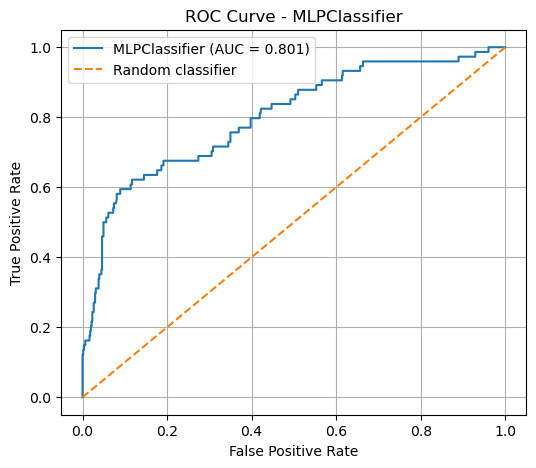

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

mlp_auc = roc_auc_score(y_test, y_proba_active_mlp)

fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(
    y_test,
    y_proba_active_mlp
)

print("MLPClassifier AUC:", round(mlp_auc, 3))
plt.figure(figsize=(6, 5))

plt.plot(fpr_mlp, tpr_mlp, label=f"MLPClassifier (AUC = {mlp_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLPClassifier")
plt.legend()
plt.grid(True)
plt.show()

A model with no useful ranking ability would follow the diagonal line, corresponding to an AUC of about 0.5. A better model bends toward the upper-left corner of the plot, indicating a higher true positive rate at a lower false positive rate.

The ROC curve is useful because it evaluates the probability scores across many possible thresholds rather than only evaluating the default threshold of 0.5.

## 3.4 Interpreting the Results for an Imbalanced Dataset

The aromatase bioassay dataset is imbalanced, meaning there are many more inactive compounds than active compounds. This affects how we interpret the MLP model.

A high accuracy score does not necessarily mean that the model is good at finding active compounds. If most molecules are inactive, a model can achieve high accuracy by predicting most molecules as inactive. Therefore, we need to ask more specific questions:

| Question | Useful metric |
|---|---|
| Is the model correct overall? | Accuracy |
| Is the model performing reasonably on both classes? | Balanced accuracy |
| When the model predicts active, is it usually right? | Precision |
| Is the model finding the active compounds? | Recall |
| Is there a balance between precision and recall? | F1 score |
| Does the model rank active compounds above inactive compounds? | AUC |

For this notebook, the most important comparison is not whether the neural network has the highest accuracy. Instead, we want to know whether it provides a useful tradeoff between identifying active compounds and avoiding too many false positives.

In [31]:
mlp_summary = pd.DataFrame({
    "Model": ["MLPClassifier"],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp],
    "Accuracy": [mlp_accuracy],
    "Balanced Accuracy": [mlp_balanced_accuracy],
    "Precision": [mlp_precision],
    "Recall": [mlp_recall],
    "F1": [mlp_f1],
    "AUC": [mlp_auc]
})

mlp_summary

,Model,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC
0,MLPClassifier,594,12,59,15,0.895588,0.59145,0.555556,0.202703,0.29703,0.801467


## 3.5 Does Changing the Hidden-Layer Structure Matter?
The `hidden_layer_sizes` parameter controls the architecture of the MLP. A value such as `(50,)` creates one hidden layer with 50 units, while `(100, 50)` creates two hidden layers: the first with 100 units and the second with 50 units.

Increasing the number of hidden layers or hidden units makes the model more flexible, but it also increases the risk of overfitting. A larger neural network is not automatically a better model, especially for a dataset with binary fingerprint features and an imbalanced activity label.

For this reason, we compare a few small MLP architectures rather than assuming that the deepest model is best.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd


mlp_architectures = {
    "MLP (25,)": (25,),
    "MLP (50,)": (50,),
    "MLP (100,)": (100,),
    "MLP (50, 25)": (50, 25),
    "MLP (100, 50)": (100, 50)
}

mlp_results = {}

for name, architecture in mlp_architectures.items():

    mlp_pipeline = Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=architecture,
            activation="relu",
            solver="adam",
            alpha=0.0001,
            max_iter=1000,
            random_state=3100,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20
        ))
    ])

    mlp_pipeline.fit(X_train, y_train)

    y_pred = mlp_pipeline.predict(X_test)
    y_prob = mlp_pipeline.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    mlp_results[name] = {
        "Hidden Layers": architecture,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_prob),
        "Iterations": mlp_pipeline.named_steps["clf"].n_iter_,
        "Final Loss": mlp_pipeline.named_steps["clf"].loss_
    }

mlp_architecture_df = pd.DataFrame(mlp_results).T
mlp_architecture_df.sort_values(by="AUC", ascending=False)

,Hidden Layers,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC,Iterations,Final Loss
"MLP (100, 50)","(100, 50)",587,19,49,25,0.9,0.653242,0.568182,0.337838,0.423729,0.814802,45,0.046748
"MLP (100,)","(100,)",599,7,61,13,0.9,0.582062,0.65,0.175676,0.276596,0.813264,38,0.150616
"MLP (25,)","(25,)",595,11,51,23,0.908824,0.646329,0.676471,0.310811,0.425926,0.811324,86,0.162351
"MLP (50, 25)","(50, 25)",588,18,53,21,0.895588,0.62704,0.538462,0.283784,0.371681,0.810476,38,0.092019
"MLP (50,)","(50,)",594,12,59,15,0.895588,0.59145,0.555556,0.202703,0.29703,0.801467,47,0.187189


# 4. Comparing MLP to Earlier Models

The MLPClassifier is only useful if we evaluate it in the same context as the earlier supervised learning models. In this section, we compare the MLP model with Naive Bayes, Logistic Regression, Support Vector Machine, Decision Tree, and Random Forest models.

To make the comparison fair, each model will use:

- the same MACCS fingerprint features,
- the same train/test split,
- the same activity labels,
- the same evaluation metrics.

This does not mean that each model is fully optimized. Instead, this comparison gives us a first-pass view of how different supervised classifiers behave on the same molecular bioassay dataset.

## 4.1 Comparison Table and ROC/AUC Comparison

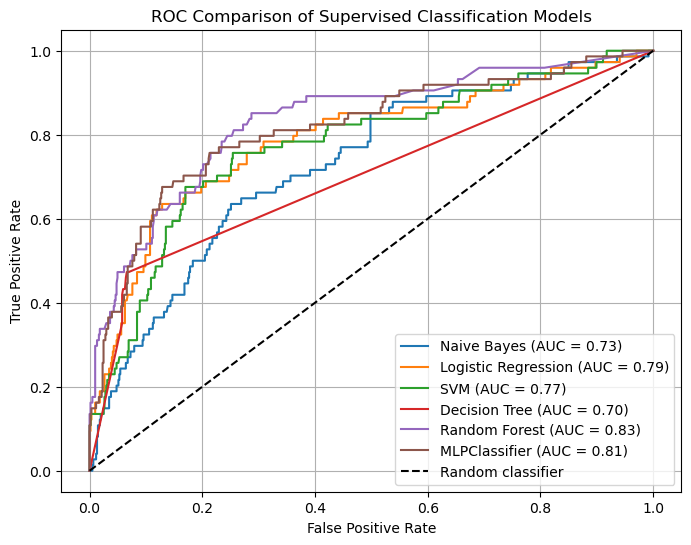

,Threshold Used,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC
Random Forest,0.500,596.0,10.0,50.0,24.0,0.911765,0.653911,0.705882,0.324324,0.444444,0.833746
MLPClassifier,0.500,587.0,19.0,49.0,25.0,0.900000,0.653242,0.568182,0.337838,0.423729,0.814802
Logistic Regression,0.500,592.0,14.0,60.0,14.0,0.891176,0.583043,0.500000,0.189189,0.274510,0.788400
SVM (Youden J = 0.114),0.114,146.0,460.0,5.0,69.0,0.316176,0.586678,0.130435,0.932432,0.228856,0.774418
SVM (default 0.5),0.500,606.0,0.0,74.0,0.0,0.891176,0.500000,0.000000,0.000000,0.000000,0.774418
Naive Bayes,0.500,474.0,132.0,34.0,40.0,0.755882,0.661359,0.232558,0.540541,0.325203,0.728682
Decision Tree,0.500,571.0,35.0,43.0,31.0,0.885294,0.680582,0.469697,0.418919,0.442857,0.700785


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import VarianceThreshold

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------------------------
# User-defined threshold for SVM from earlier Youden's J analysis
# -------------------------------------------------

svm_youden_threshold = 0.114


# -------------------------------------------------
# Define model pipelines
# -------------------------------------------------

models = {
    "Naive Bayes": Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", BernoulliNB())
    ]),

    "Logistic Regression": Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=3100
        ))
    ]),

    "SVM (default 0.5)": Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", SVC(
            kernel="linear",
            probability=True,
            random_state=3100
        ))
    ]),

    "SVM (Youden J = 0.114)": Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", SVC(
            kernel="linear",
            probability=True,
            random_state=3100
        ))
    ]),

    "Decision Tree": Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", DecisionTreeClassifier(
            random_state=3100
        ))
    ]),

    "Random Forest": Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            random_state=3100
        ))
    ]),

    "MLPClassifier": Pipeline([
        ("var", VarianceThreshold(threshold=0.0)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(100,50),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            max_iter=1000,
            random_state=3100,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20
        ))
    ])
}


# -------------------------------------------------
# Train models, collect metrics, and plot ROC curves
# -------------------------------------------------

results = {}
confusion_matrices = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Probability scores for ROC/AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # -------------------------------------------------
    # Apply model-specific prediction rule
    # -------------------------------------------------
    if name == "SVM (Youden J = 0.114)":
        y_pred = (y_prob >= svm_youden_threshold).astype(int)
        threshold_used = svm_youden_threshold
    else:
        y_pred = model.predict(X_test)
        threshold_used = 0.5

    # -------------------------------------------------
    # Confusion matrix
    # -------------------------------------------------
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    confusion_matrices[name] = cm

    # -------------------------------------------------
    # Metrics
    # -------------------------------------------------
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1_val = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Threshold Used": threshold_used,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": acc,
        "Balanced Accuracy": bal_acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1_val,
        "AUC": auc
    }

    # -------------------------------------------------
    # ROC curve
    # Note: both SVM rows generate the same ROC curve,
    # because ROC depends on y_prob, not the selected threshold.
    # -------------------------------------------------
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    if name.startswith("SVM"):
        # Only plot one ROC curve for the two SVM variants
        if name == "SVM (default 0.5)":
            plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.2f})")
    else:
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")


# -------------------------------------------------
# Plot ROC comparison
# -------------------------------------------------

plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of Supervised Classification Models")
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------------------------
# Display comparison table
# -------------------------------------------------

comparison_df = pd.DataFrame(results).T

comparison_df = comparison_df[
    [
        "Threshold Used",
        "TN", "FP", "FN", "TP",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC"
    ]
]

comparison_df = comparison_df.sort_values(by="AUC", ascending=False)

comparison_df

## 4.2 Confusion Matrix Comparison

The confusion matrix values allow us to see how each model makes correct and incorrect predictions. This is especially useful for an imbalanced dataset because two models can have similar accuracy while making very different kinds of errors.

For this binary classification problem:

```text
TN = inactive compounds correctly predicted as inactive
FP = inactive compounds incorrectly predicted as active
FN = active compounds incorrectly predicted as inactive
TP = active compounds correctly predicted as active

In [39]:
confusion_summary = comparison_df[
    ["TN", "FP", "FN", "TP", "Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1", "AUC"]
].copy()

confusion_summary

,TN,FP,FN,TP,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC
Random Forest,596.0,10.0,50.0,24.0,0.911765,0.653911,0.705882,0.324324,0.444444,0.833746
MLPClassifier,587.0,19.0,49.0,25.0,0.900000,0.653242,0.568182,0.337838,0.423729,0.814802
Logistic Regression,592.0,14.0,60.0,14.0,0.891176,0.583043,0.500000,0.189189,0.274510,0.788400
SVM (Youden J = 0.114),146.0,460.0,5.0,69.0,0.316176,0.586678,0.130435,0.932432,0.228856,0.774418
SVM (default 0.5),606.0,0.0,74.0,0.0,0.891176,0.500000,0.000000,0.000000,0.000000,0.774418
Naive Bayes,474.0,132.0,34.0,40.0,0.755882,0.661359,0.232558,0.540541,0.325203,0.728682
Decision Tree,571.0,35.0,43.0,31.0,0.885294,0.680582,0.469697,0.418919,0.442857,0.700785


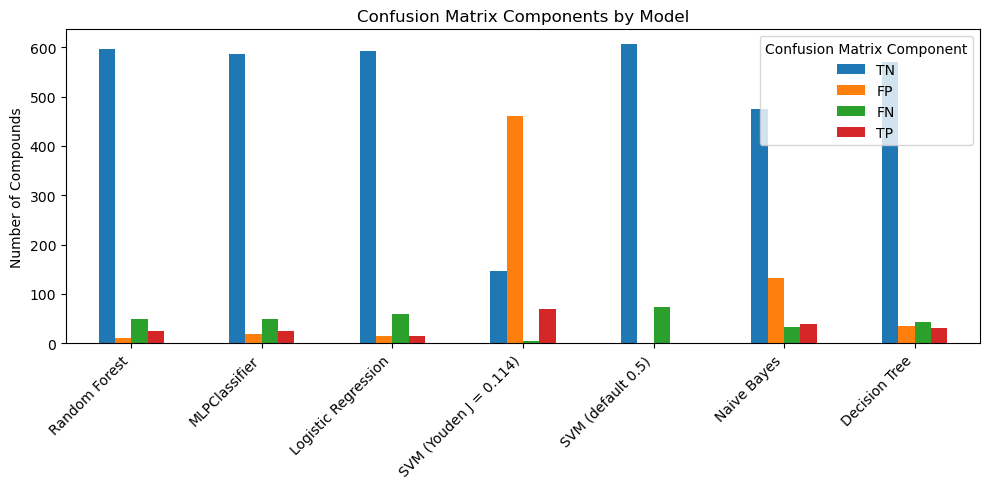

In [40]:
confusion_summary[["TN", "FP", "FN", "TP"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Number of Compounds")
plt.title("Confusion Matrix Components by Model")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Confusion Matrix Component")
plt.tight_layout()
plt.show()

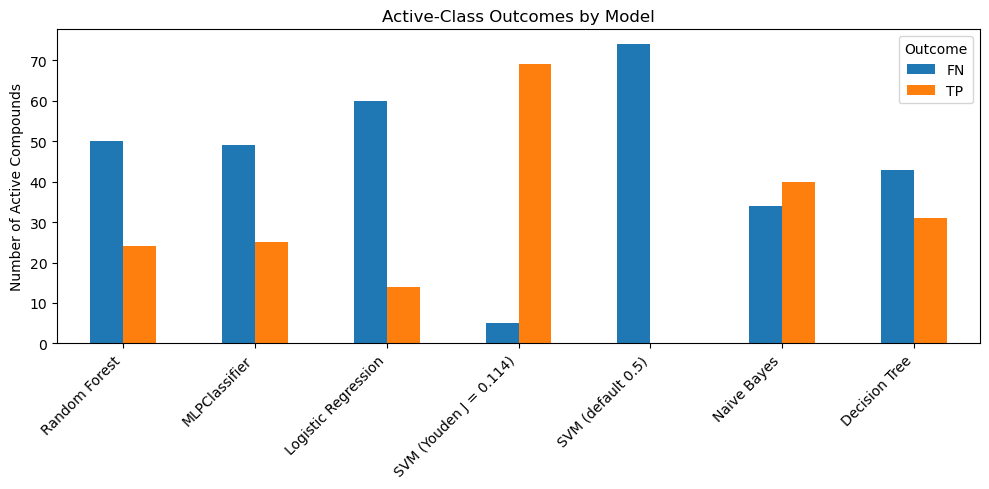

In [41]:
confusion_summary[["FN", "TP"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Number of Active Compounds")
plt.title("Active-Class Outcomes by Model")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

## 4.4 Interpreting Tradeoffs Between Models

The model-comparison results show that no single classifier is best by every metric. This is common in imbalanced classification problems, especially when the minority class is the class of greatest scientific interest.

In this dataset, the inactive class is much larger than the active class. Therefore, models can achieve high accuracy by correctly predicting many inactive compounds while still missing many active compounds. For this reason, accuracy alone is not enough to judge model performance.

The **Random Forest** model had the highest AUC in this comparison, with an AUC of about 0.83. It also had high overall accuracy and high precision for the active class. However, its recall was only about 0.32, meaning it identified fewer than one-third of the active compounds in the test set. This model was conservative: when it predicted a compound as active, it was often correct, but it missed many active compounds.

The **MLPClassifier** had an AUC of about 0.80, which was slightly higher than Logistic Regression and SVM, but lower than Random Forest. At the default classification threshold, the MLP identified 15 of the 74 active compounds in the test set. This was slightly better than Logistic Regression, which identified 14 active compounds, but the difference was small. In this comparison, the neural-network classifier did not dramatically outperform the simpler linear model.

The **Logistic Regression** model behaved similarly to the MLPClassifier. It had high accuracy because it correctly identified most inactive compounds, but it had low recall for the active class. This means that, at the default threshold, Logistic Regression missed most of the active compounds.

The **SVM at the default threshold of 0.5** predicted all compounds as inactive. This produced a high accuracy because most compounds were inactive, but it gave zero recall, zero precision, and zero F1 score for the active class. This is an important example of why accuracy can be misleading in an imbalanced dataset.

The **SVM using the lower threshold of 0.114** had the opposite behavior. It found 69 of the 74 active compounds, giving it the highest recall in the comparison. However, it also incorrectly classified 460 inactive compounds as active. This produced very low precision and low overall accuracy. This model would be useful only if the scientific priority were to find as many actives as possible, even at the cost of many false positives.

The **Naive Bayes** model had lower AUC than Random Forest, MLP, Logistic Regression, and SVM, but it found more active compounds than several of those models at the default threshold. It identified 40 of the 74 active compounds, giving it better recall than Random Forest, MLP, and Logistic Regression. However, this came with 132 false positives, so its precision was relatively low.

The **Decision Tree** had the highest balanced accuracy in this comparison. It identified 31 of the 74 active compounds and produced fewer false positives than Naive Bayes. However, its AUC was the lowest among the models shown here. This suggests that the particular class predictions at the default threshold were useful, but the model's overall ranking of active versus inactive compounds was not as strong as the Random Forest or MLPClassifier.

Overall, these results show that model choice depends on the scientific goal. If the goal is to minimize false positives, Random Forest may be attractive because of its high precision. If the goal is to find more active compounds, Naive Bayes or a threshold-adjusted model may be more useful. If the goal is to rank compounds for follow-up testing, AUC becomes especially important, and Random Forest performs best in this comparison.

The MLPClassifier is therefore best interpreted as one supervised classifier among several. It introduces neural-network modeling into the workflow, but it does not automatically outperform simpler or more interpretable models. For this molecular fingerprint dataset, the MLPClassifier performed reasonably well, but Random Forest gave the strongest AUC and Naive Bayes gave stronger recall at the default threshold.

# 5. What Neural Networks Do—and Do Not—Solve

Neural networks are powerful supervised learning models, but they do not automatically solve every classification problem. In this notebook, we used scikit-learn's `MLPClassifier` to introduce a neural-network model within the same workflow used for the earlier classifiers.

The MLPClassifier performed reasonably well on the MACCS fingerprint dataset. Its AUC was higher than Naive Bayes, Decision Tree, Logistic Regression, and SVM in this comparison, but it was lower than Random Forest. At the default classification threshold, the MLPClassifier also missed many active compounds. This means that, although the neural network learned useful patterns from the fingerprint features, it did not eliminate the main challenge of the dataset: identifying the minority active class.

## 5.1 Neural Networks Are Powerful but Not Magic

A common misconception is that neural networks are automatically better than simpler machine learning models. This comparison shows why that assumption is not safe. The MLPClassifier introduced a more flexible model, but Random Forest still produced the highest AUC in this run.

Neural networks can learn nonlinear combinations of features, but their performance depends on the data, the feature representation, the model architecture, the training process, and the evaluation metric. A more complex model is not always a better model.

## 5.2 Class Imbalance Still Matters

The aromatase dataset is imbalanced, with many more inactive compounds than active compounds. This affected every model in the comparison, including the MLPClassifier.

At the default threshold, several models had high accuracy but low recall for the active class. This means they correctly classified many inactive compounds but missed many active compounds. The SVM at the default threshold is the most extreme example: it predicted all compounds as inactive, giving high accuracy but zero recall for active compounds.

This shows why accuracy alone is not enough for imbalanced classification problems. Precision, recall, F1 score, balanced accuracy, ROC curves, and AUC are all needed to understand model behavior.

## 5.3 Feature Representation Still Matters

The neural network did not work directly with molecular structures. It worked with MACCS fingerprints, which represent each molecule as a binary vector of structural features.

This means that the model can only learn patterns that are present in the fingerprint representation. If important chemical information is missing from the fingerprint, the neural network cannot recover it. Other molecular representations, such as Morgan fingerprints, molecular descriptors, graph-based representations, or learned molecular embeddings, could lead to different model behavior.

Changing the classifier is only one way to change a machine learning model. Changing the molecular representation can be just as important.

## 5.4 Model Evaluation Still Matters

The comparison in this notebook reinforces one of the main themes of this supervised learning module: model evaluation must be tied to the scientific goal.

If the goal is to minimize false positives, a high-precision model may be preferred. If the goal is to find as many active compounds as possible, recall may be more important. If the goal is to rank compounds for follow-up testing, AUC may be especially useful.

The MLPClassifier is therefore best understood as another supervised classifier in the model-comparison workflow. It introduces neural-network modeling, but it does not replace the need for careful evaluation, threshold selection, and scientific judgment.

